In [51]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, IntSlider
import mplcursors
# use a supported interactive backend for Jupyter notebooks
%matplotlib inline




In [52]:
# Constants
# IMU log paths
IMU_LOG_WRIST_Y_BACK_OF_HAND = "../raw_data/breadboard_demo/controlled_y_back_of_hand/imu_log_wrist_y_back_of_hand.csv"
APPLE_IMU_LOG_WRIST_Y_BACK_OF_HAND = "../raw_data/breadboard_demo/controlled_y_back_of_hand/WristMotion_y_back_of_hand.csv"
IMU_LOG_WRIST_Y_BREADBOARD = "../raw_data/breadboard_demo/controlled_y_holding_breadboard/imu_log_wrist_y_breadboard.csv"
APPLE_IMU_LOG_WRIST_Y_BREADBOARD = "../raw_data/breadboard_demo/controlled_y_holding_breadboard/WristMotion_y_breadboard.csv"

# Change filenames to your actual paths
# watch_path = APPLE_IMU_LOG_WRIST_Y_BACK_OF_HAND
# imu_path   = IMU_LOG_WRIST_Y_BACK_OF_HAND  
watch_path = APPLE_IMU_LOG_WRIST_Y_BREADBOARD
imu_path   = IMU_LOG_WRIST_Y_BREADBOARD  

watch = pd.read_csv(watch_path)
imu   = pd.read_csv(imu_path)

imu.head()

,time,seconds_elapsed,rotationRateX,rotationRateY,rotationRateZ,gravityX,gravityY,gravityZ,accelerationX,accelerationY,accelerationZ,quaternionW,quaternionX,quaternionY,quaternionZ,pitch,roll,yaw
0,24184,0.013656,0.000000,0.000000,0.000000,0.001854,0.000750,0.999998,0.019874,0.008039,-0.030515,9.000000e-08,0.000927,0.000375,0.999999,-0.001854,0.000750,3.141592
1,56976,0.046448,-0.081404,0.108184,0.136162,0.003753,0.001303,0.999992,0.057526,0.017008,-0.021477,-1.199000e-05,0.001877,0.000651,0.999998,-0.003753,0.001303,3.141614
2,89676,0.079148,-0.083536,0.210372,0.034640,0.001922,0.002170,0.999996,-0.022918,0.011257,-0.012935,-1.360000e-05,0.000961,0.001085,0.999999,-0.001922,0.002170,3.141618
3,122392,0.111864,-0.109516,0.273124,0.126570,0.000045,0.002961,0.999996,-0.022262,0.009978,0.024174,-2.320000e-05,0.000023,0.001481,0.999999,-0.000045,0.002961,3.141639
4,155152,0.144624,-0.144289,0.211305,0.112314,-0.001986,0.003084,0.999993,-0.031706,0.002287,-0.030999,-3.165000e-05,-0.000993,0.001542,0.999998,0.001986,0.003084,3.141659


In [58]:
watch = watch.sort_values("seconds_elapsed").reset_index(drop=True)
imu   = imu.sort_values("seconds_elapsed").reset_index(drop=True)

watch["t_rel"] = watch["seconds_elapsed"] - watch["seconds_elapsed"].iloc[0]
imu["t_rel"]   = imu["seconds_elapsed"]   - imu["seconds_elapsed"].iloc[0]
imu.head()


,time,seconds_elapsed,rotationRateX,rotationRateY,rotationRateZ,gravityX,gravityY,gravityZ,accelerationX,accelerationY,accelerationZ,quaternionW,quaternionX,quaternionY,quaternionZ,pitch,roll,yaw,t_rel,seconds_shifted
0,24184,0.013656,0.000000,0.000000,0.000000,0.001854,0.000750,0.999998,0.019874,0.008039,-0.030515,9.000000e-08,0.000927,0.000375,0.999999,-0.001854,0.000750,3.141592,0.000000,4.763656
1,56976,0.046448,-0.081404,0.108184,0.136162,0.003753,0.001303,0.999992,0.057526,0.017008,-0.021477,-1.199000e-05,0.001877,0.000651,0.999998,-0.003753,0.001303,3.141614,0.032792,4.796448
2,89676,0.079148,-0.083536,0.210372,0.034640,0.001922,0.002170,0.999996,-0.022918,0.011257,-0.012935,-1.360000e-05,0.000961,0.001085,0.999999,-0.001922,0.002170,3.141618,0.065492,4.829148
3,122392,0.111864,-0.109516,0.273124,0.126570,0.000045,0.002961,0.999996,-0.022262,0.009978,0.024174,-2.320000e-05,0.000023,0.001481,0.999999,-0.000045,0.002961,3.141639,0.098208,4.861864
4,155152,0.144624,-0.144289,0.211305,0.112314,-0.001986,0.003084,0.999993,-0.031706,0.002287,-0.030999,-3.165000e-05,-0.000993,0.001542,0.999998,0.001986,0.003084,3.141659,0.130968,4.894624


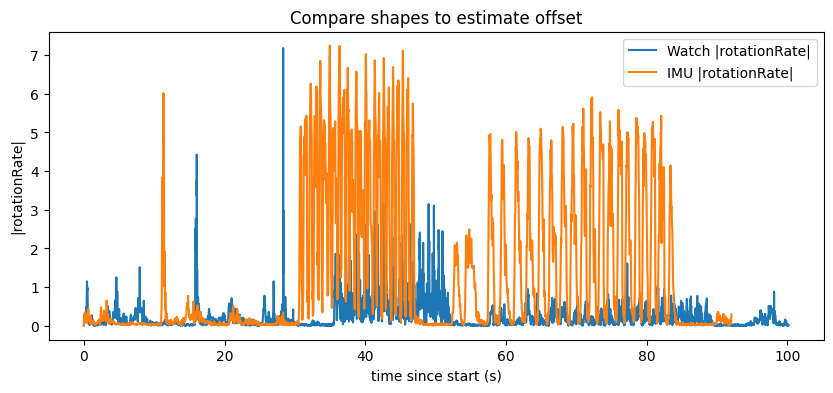

,time,seconds_elapsed,rotationRateX,rotationRateY,rotationRateZ,gravityX,gravityY,gravityZ,accelerationX,accelerationY,accelerationZ,quaternionW,quaternionX,quaternionY,quaternionZ,pitch,roll,yaw,t_rel,seconds_shifted
0,24184,0.013656,0.000000,0.000000,0.000000,0.001854,0.000750,0.999998,0.019874,0.008039,-0.030515,9.000000e-08,0.000927,0.000375,0.999999,-0.001854,0.000750,3.141592,0.000000,4.763656
1,56976,0.046448,-0.081404,0.108184,0.136162,0.003753,0.001303,0.999992,0.057526,0.017008,-0.021477,-1.199000e-05,0.001877,0.000651,0.999998,-0.003753,0.001303,3.141614,0.032792,4.796448
2,89676,0.079148,-0.083536,0.210372,0.034640,0.001922,0.002170,0.999996,-0.022918,0.011257,-0.012935,-1.360000e-05,0.000961,0.001085,0.999999,-0.001922,0.002170,3.141618,0.065492,4.829148
3,122392,0.111864,-0.109516,0.273124,0.126570,0.000045,0.002961,0.999996,-0.022262,0.009978,0.024174,-2.320000e-05,0.000023,0.001481,0.999999,-0.000045,0.002961,3.141639,0.098208,4.861864
4,155152,0.144624,-0.144289,0.211305,0.112314,-0.001986,0.003084,0.999993,-0.031706,0.002287,-0.030999,-3.165000e-05,-0.000993,0.001542,0.999998,0.001986,0.003084,3.141659,0.130968,4.894624


In [66]:
# Plot Mag

def rotation_mag(df, prefix="rotationRate"):
    return np.sqrt(
        df[f"{prefix}X"]**2 +
        df[f"{prefix}Y"]**2 +
        df[f"{prefix}Z"]**2
    )

plt.figure(figsize=(10, 4))

plt.plot(watch["t_rel"], rotation_mag(watch), label="Watch |rotationRate|")
plt.plot(imu["t_rel"],   rotation_mag(imu),   label="IMU |rotationRate|")

plt.xlabel("time since start (s)")
plt.ylabel("|rotationRate|")
plt.legend()
plt.title("Compare shapes to estimate offset")
plt.show()

imu.head()



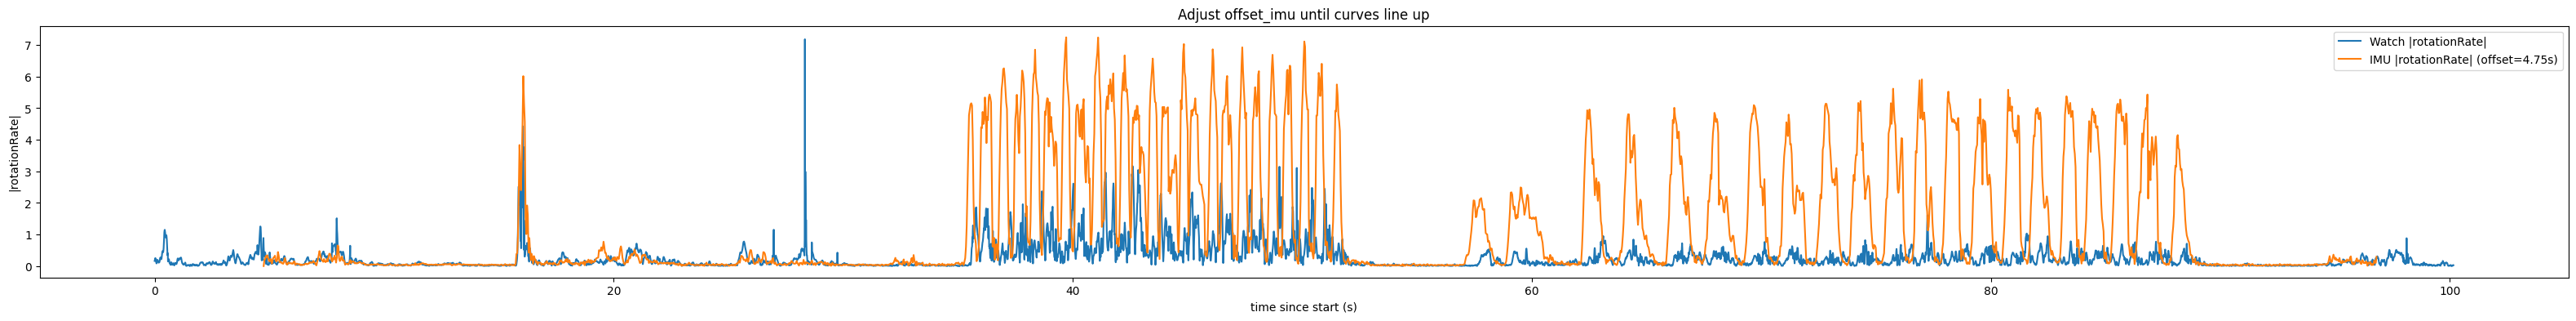

,time,seconds_elapsed,rotationRateX,rotationRateY,rotationRateZ,gravityX,gravityY,gravityZ,accelerationX,accelerationY,accelerationZ,quaternionW,quaternionX,quaternionY,quaternionZ,pitch,roll,yaw,t_rel,seconds_shifted
0,24184,0.013656,0.000000,0.000000,0.000000,0.001854,0.000750,0.999998,0.019874,0.008039,-0.030515,9.000000e-08,0.000927,0.000375,0.999999,-0.001854,0.000750,3.141592,0.000000,4.763656
1,56976,0.046448,-0.081404,0.108184,0.136162,0.003753,0.001303,0.999992,0.057526,0.017008,-0.021477,-1.199000e-05,0.001877,0.000651,0.999998,-0.003753,0.001303,3.141614,0.032792,4.796448
2,89676,0.079148,-0.083536,0.210372,0.034640,0.001922,0.002170,0.999996,-0.022918,0.011257,-0.012935,-1.360000e-05,0.000961,0.001085,0.999999,-0.001922,0.002170,3.141618,0.065492,4.829148
3,122392,0.111864,-0.109516,0.273124,0.126570,0.000045,0.002961,0.999996,-0.022262,0.009978,0.024174,-2.320000e-05,0.000023,0.001481,0.999999,-0.000045,0.002961,3.141639,0.098208,4.861864
4,155152,0.144624,-0.144289,0.211305,0.112314,-0.001986,0.003084,0.999993,-0.031706,0.002287,-0.030999,-3.165000e-05,-0.000993,0.001542,0.999998,0.001986,0.003084,3.141659,0.130968,4.894624


In [67]:
offset_imu = 4.75  # <-- try a guess here (positive = IMU moves right)

plt.figure(figsize=(40, 4))

plt.plot(watch["t_rel"], rotation_mag(watch), label="Watch |rotationRate|")
plt.plot(imu["t_rel"] + offset_imu, rotation_mag(imu), label=f"IMU |rotationRate| (offset={offset_imu}s)")

plt.xlabel("time since start (s)")
plt.ylabel("|rotationRate|")
plt.legend()
plt.title("Adjust offset_imu until curves line up")
plt.show()

imu.head()


In [77]:
# 1) Make sure t_rel exists
watch = watch.sort_values("seconds_elapsed").reset_index(drop=True)
imu   = imu.sort_values("seconds_elapsed").reset_index(drop=True)

watch["t_rel"] = watch["seconds_elapsed"] - watch["seconds_elapsed"].iloc[0]
imu["t_rel"]   = imu["seconds_elapsed"]   - imu["seconds_elapsed"].iloc[0]

# 2) Apply the offset you found from the plot
offset_rel = 4.8   # from your t_rel alignment
imu["t_rel_shifted"] = imu["t_rel"] + offset_rel

# 3) Merge on relative time
merged = pd.merge_asof(
    watch.sort_values("t_rel"),
    imu.sort_values("t_rel_shifted"),
    left_on="t_rel",
    right_on="t_rel_shifted",
    direction="nearest",
    tolerance=0.02,        # 20 ms; increase if needed
    suffixes=("_watch", "_imu")
)

merged.head()


,time_watch,seconds_elapsed_watch,rotationRateX_watch,rotationRateY_watch,rotationRateZ_watch,gravityX_watch,gravityY_watch,gravityZ_watch,accelerationX_watch,accelerationY_watch,...,quaternionW_imu,quaternionX_imu,quaternionY_imu,quaternionZ_imu,pitch_imu,roll_imu,yaw_imu,t_rel_imu,seconds_shifted,t_rel_shifted
0,1763354779295836416,4.662837,-0.142403,0.077667,-0.003477,0.050231,-0.219198,-0.974387,-0.008376,0.044118,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1763354779305883392,4.672884,-0.161054,0.098163,-0.022089,0.051132,-0.217731,-0.974669,-0.012084,0.032367,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1763354779315929344,4.682930,-0.203852,0.115896,-0.028286,0.052249,-0.215928,-0.975010,-0.016239,0.010713,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1763354779325975296,4.692976,-0.223338,0.109244,-0.037635,0.053435,-0.213797,-0.975416,-0.012542,-0.008020,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1763354779336022272,4.703022,-0.227079,0.081334,-0.036463,0.054502,-0.211548,-0.975847,-0.004805,-0.014297,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


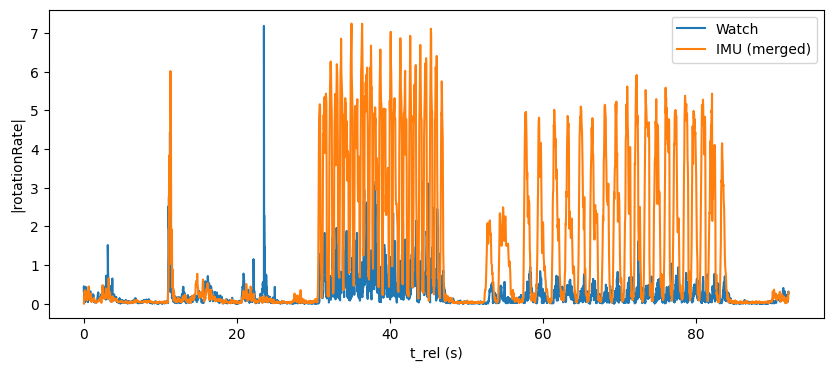

In [78]:
def rot_mag(df, suffix):
    return np.sqrt(
        df[f"rotationRateX{suffix}"]**2 +
        df[f"rotationRateY{suffix}"]**2 +
        df[f"rotationRateZ{suffix}"]**2
    )

plt.figure(figsize=(10,4))
plt.plot(merged["t_rel_imu"], rot_mag(merged, "_watch"), label="Watch")
plt.plot(merged["t_rel_imu"], rot_mag(merged, "_imu"),   label="IMU (merged)")
plt.xlabel("t_rel (s)")
plt.ylabel("|rotationRate|")
plt.legend()
plt.show()

In [79]:
output_path = "../raw_data/breadboard_demo/controlled_y_holding_breadboard/merged_data.csv"  # name it whatever you like
merged.to_csv(output_path, index=False)
output_path

'../raw_data/breadboard_demo/controlled_y_holding_breadboard/merged_data.csv'